In [5]:
import pandas as pd

# -------------------------------
# 1) Load ground truth (drop TotalCells, collect sorted cols)
# -------------------------------
gt_files = {
    "GT_BDa_Outer": "COO-Decon-Pseudobulks/TSP-BDa_Outer_Random_v2C_All-Proportions.txt",
    "GT_BDa_Inner": "COO-Decon-Pseudobulks/TSP-BDa_Inner_Random_v2C_All-Proportions.txt",
    "GT_HBA":      "COO-Decon-Pseudobulks/TSP-HBA_Inner_Random_v2C_All-Proportions.txt",
}

gt_data = {}
for name, path in gt_files.items():
    df = pd.read_csv(path, sep="\t", index_col=0)
    if "TotalCells" in df.columns:
        df = df.drop(columns=["TotalCells"])
    gt_data[name] = sorted(df.columns.tolist())

# -------------------------------
# 2) Load NEW BayesPrism files
# -------------------------------
bp_files = {
    "BP_BDa_Outer": "../COO-Decon-KnownTissue/BayesPrism-Deconvolutions/TSP-BDa_Outer_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism.txt",
    "BP_BDa_Inner": "../COO-Decon-KnownTissue/BayesPrism-Deconvolutions/TSP-BDa_Inner_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism.txt",
    "BP_HBA":       "../COO-Decon-KnownTissue/BayesPrism-Deconvolutions/TSP-HBA_Inner_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism.txt",
}

# -------------------------------
# 3) Load previous comparison file → build rename maps
# -------------------------------
comparison_df = pd.read_csv("COO-Decon-Pseudobulks/Column_Comparison_GT_vs_BayesPrism_Final.txt", sep="\t")

rename_map_bda_outer = dict(
    zip(comparison_df["BP_BDa_Outer"].dropna(), comparison_df["GT_BDa_Outer"].dropna())
)
rename_map_bda_inner = dict(
    zip(comparison_df["BP_BDa_Inner"].dropna(), comparison_df["GT_BDa_Inner"].dropna())
)
rename_map_hba = dict(
    zip(comparison_df["BP_HBA"].dropna(), comparison_df["GT_HBA"].dropna())
)

# -------------------------------
# 4) Apply manual fixes for mismatches (as before)
# -------------------------------
rename_map_hba.update({
    "basal.cell.of.prostate.epithelium": "basal cell of prostate epithelium",
    "basal.cell.medullary.thymic.epithelial.cell": "basal cell/medullary thymic epithelial cell",
})
rename_map_bda_outer.update({
    "endothelial.cell.endothelial.cell.of.lymphatic.vessel.vein.endothelial.cell":
        "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell",
    "endothelial.cell.of.arteriole.endothelial.cell.of.venule":
        "endothelial cell of arteriole/endothelial cell of venule",
})
rename_map_bda_inner.update({
    "endothelial.cell.endothelial.cell.of.lymphatic.vessel.vein.endothelial.cell":
        "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell",
    "endothelial.cell.of.arteriole.endothelial.cell.of.venule":
        "endothelial cell of arteriole/endothelial cell of venule",
})

rename_maps = {
    "BP_BDa_Outer": rename_map_bda_outer,
    "BP_BDa_Inner": rename_map_bda_inner,
    "BP_HBA":       rename_map_hba,
}

# -------------------------------
# 5) Load new BP files, apply rename maps
# -------------------------------
bp_data = {}
bp_frames = {}
for name, path in bp_files.items():
    df = pd.read_csv(path, sep="\t", index_col=0)
    df = df.rename(columns=rename_maps[name])
    bp_frames[name] = df
    bp_data[name] = sorted(df.columns.tolist())

# -------------------------------
# 6) Check match counts
# -------------------------------
for pair in [("GT_BDa_Outer", "BP_BDa_Outer"),
             ("GT_BDa_Inner", "BP_BDa_Inner"),
             ("GT_HBA", "BP_HBA")]:
    gt_set = set(gt_data[pair[0]])
    bp_set = set(bp_data[pair[1]])
    common = gt_set & bp_set
    print(f"{pair[1]}: {len(common)} / {len(gt_set)} columns match GT")

# -------------------------------
# 7) Save renamed versions with _renamed.txt
# -------------------------------
for name, path in bp_files.items():
    out_path = path.replace(".txt", "_renamed.txt")
    bp_frames[name].to_csv(out_path, sep="\t")
    print(f"Saved renamed file: {out_path}")


BP_BDa_Outer: 78 / 78 columns match GT
BP_BDa_Inner: 80 / 80 columns match GT
BP_HBA: 69 / 69 columns match GT
Saved renamed file: ../COO-Decon-KnownTissue/BayesPrism-Deconvolutions/TSP-BDa_Outer_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism_renamed.txt
Saved renamed file: ../COO-Decon-KnownTissue/BayesPrism-Deconvolutions/TSP-BDa_Inner_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism_renamed.txt
Saved renamed file: ../COO-Decon-KnownTissue/BayesPrism-Deconvolutions/TSP-HBA_Inner_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism_renamed.txt


In [11]:
import pandas as pd
import os

# Directories to process
dirs = [
    "TSP-BDa_Inner_300_1500_10-GTEx-Brain",
    "TSP-BDa_Outer_300_1500_10-GTEx-Brain",
    "TSP-HBA_Inner_300_1500_10-GTEx-Brain"
]

# Columns to drop for specific files
drop_cols = {
    "nuSVR_CountsRMSE_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped.txt": [
        "nuValue", "CValue", "RMSE-PredictedCounts"
    ],
    "CIBERSORTx_Results.txt": [
        "P-value", "Correlation", "RMSE"
    ]
}

# Process each directory
for d in dirs:
    print(f"\nProcessing directory: {d}")
    
    for fname in os.listdir(d):
        fpath = os.path.join(d, fname)

        # Only process .txt and .tsv files
        if not (fname.endswith(".txt") or fname.endswith(".tsv")):
            continue

        try:
            # Read file
            df = pd.read_csv(fpath, sep="\t")

            # Drop unwanted columns if applicable
            if fname in drop_cols:
                df = df.drop(columns=[c for c in drop_cols[fname] if c in df.columns])

            # Normalize values per row (excluding first column)
            sample_col = df.columns[0]
            value_cols = df.columns[1:]

            df[value_cols] = df[value_cols].div(df[value_cols].sum(axis=1), axis=0) * 100
            df[value_cols] = df[value_cols].round(2)

            # Save with _normalized suffix in same directory
            base, ext = os.path.splitext(fname)
            outname = f"{base}_normalized{ext}"
            outpath = os.path.join(d, outname)

            df.to_csv(outpath, sep="\t", index=False)

            print(f"Processed: {fname} → {outname}")

        except Exception as e:
            print(f"Skipped {fname} (error: {e})")



Processing directory: TSP-BDa_Inner_300_1500_10-GTEx-Brain
Processed: TSP-BDa_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv → TSP-BDa_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results_normalized.tsv
Processed: nuSVR_CountsRMSE_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped.txt → nuSVR_CountsRMSE_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_normalized.txt
Processed: TSP-BDa_Inner_100each_seed42_filtered_GTEx-Brain_MuSiC.txt → TSP-BDa_Inner_100each_seed42_filtered_GTEx-Brain_MuSiC_normalized.txt
Processed: QP_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_composition.txt → QP_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_composition_normalized.txt
Processed: TSP-BDa_Inner_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism_renamed.txt → TSP-BDa_Inner_100each_seed42_filtered_20250830_GeneId_Brain_50PerRegion-Unique.OnlyInBrainRemapped_BayesPrism_renamed_normalized.txt



# Cell types of interest for the TSP-HBA
cell_types_of_interest_HBA = ["Bergmann glial cell/astrocyte/ependymal cell", "neuron", "endothelial cell/endothelial cell of arteriole/endothelial cell of lymphatic vessel/endothelial cell of venule/vein endothelial cell", "mural cell/pericyte", "oligodendrocyte", "oligodendrocyte precursor cell", "central nervous system macrophage", "choroid plexus epithelial cell", "adventitial cell/fibroblast/mesenchymal stem cell of adipose tissue/stromal cell"]

cell_types_of_interest_HBA_BayesPrism = ["Bergmann.glial.cell.astrocyte.ependymal.cell","neuron", "endothelial.cell.endothelial.cell.of.arteriole.endothelial.cell.of.lymphatic.vessel.endothelial.cell.of.venule.vein.endothelial.cell", "mural.cell.pericyte", "oligodendrocyte", "oligodendrocyte.precursor.cell", "central.nervous.system.macrophage", "choroid.plexus.epithelial.cell", "adventitial.cell.fibroblast.mesenchymal.stem.cell.of.adipose.tissue.stromal.cell"]

# Cell types of interest for the TSP-BDa
cell_types_of_interest_BDa = ["neurons", "microglia", "OPC/astrocytes/oligodendrocytes", "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell"]

cell_types_of_interest_BDa_BayesPrism = ["neurons", "microglia", "OPC.astrocytes.oligodendrocytes", "endothelial.cell.endothelial.cell.of.lymphatic.vessel.vein.endothelial.cell"]

In [8]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.collections import PolyCollection

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# -----------------------------
# Publication-friendly styling
# -----------------------------
rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11
})
sns.set_style("whitegrid")

output_dir = "Results_SumBrain_Violins"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Directories (datasets)
# -----------------------------
dirs = [
    "TSP-BDa_Inner_300_1500_10-GTEx-Brain",
    "TSP-BDa_Outer_300_1500_10-GTEx-Brain",
    "TSP-HBA_Inner_300_1500_10-GTEx-Brain"
]

# Dataset labels for legend
dataset_label_map = {
    "TSP-BDa_Inner_300_1500_10-GTEx-Brain": "BDa_Inner",
    "TSP-BDa_Outer_300_1500_10-GTEx-Brain": "BDa_Outer",
    "TSP-HBA_Inner_300_1500_10-GTEx-Brain": "HBA_Inner",
}
dataset_order = ["BDa_Inner", "BDa_Outer", "HBA_Inner"]

# -----------------------------
# Cell types of interest
# -----------------------------
cell_types_of_interest_HBA = [
    "Bergmann glial cell/astrocyte/ependymal cell", "neuron",
    "endothelial cell/endothelial cell of arteriole/endothelial cell of lymphatic vessel/endothelial cell of venule/vein endothelial cell",
    "mural cell/pericyte", "oligodendrocyte", "oligodendrocyte precursor cell",
    "central nervous system macrophage", "choroid plexus epithelial cell",
    "adventitial cell/fibroblast/mesenchymal stem cell of adipose tissue/stromal cell"
]

cell_types_of_interest_BDa = [
    "neurons", "microglia", "OPC/astrocytes/oligodendrocytes",
    "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell"
]

# -----------------------------
# Tools
# -----------------------------
tool_map = {
    'BayesPrism': 'BayesPrism',
    'MuSiC': 'MuSiC',
    'CIBERSORTx': 'CIBERSORTx',
    'NNLS': 'NNLS',
    'nuSVR': 'nuSVR',
    'QP': 'QP',
    'ReDeconv': 'ReDeconv'
}
tool_order = list(tool_map.values())

# -----------------------------
# Collect results
# -----------------------------
all_data = []

for d in dirs:
    for fname in os.listdir(d):
        if not (fname.endswith("_normalized.txt") or fname.endswith("_normalized.tsv")):
            continue

        fpath = os.path.join(d, fname)
        try:
            df = pd.read_csv(fpath, sep="\t")

            # Choose cell types list
            if "HBA" in d:
                cell_types = cell_types_of_interest_HBA
            else:
                cell_types = cell_types_of_interest_BDa

            available_types = [c for c in df.columns if c in cell_types]
            if not available_types:
                continue

            sample_col = df.columns[0]

            # Sum brain proportions per sample
            df["SumBrain"] = df[available_types].sum(axis=1)

            # Determine tool from filename
            tool = next((v for k, v in tool_map.items() if k in fname), "Unknown")
            if tool == "Unknown":
                continue

            tmp = df[[sample_col, "SumBrain"]].copy()
            tmp["Tool"] = tool
            tmp["Dataset"] = dataset_label_map.get(d, d)
            all_data.append(tmp)

        except Exception as e:
            print(f"Skipped {fname} (error: {e})")

# -----------------------------
# Plot
# -----------------------------
if not all_data:
    print("No data collected for plotting.")
else:
    combined = pd.concat(all_data, ignore_index=True)

    # Optional: summary table to console
    summary = (
        combined.groupby(["Dataset", "Tool"])["SumBrain"]
        .agg(["mean", "median", "count"])
        .reset_index()
        .sort_values(["Dataset", "Tool"])
    )
    pd.set_option("display.float_format", "{:.2f}".format)
    print("\nSummary statistics (Summed brain cell type proportions):")
    print(summary)

    # Ensure ordering is consistent
    combined["Tool"] = pd.Categorical(combined["Tool"], categories=tool_order, ordered=True)
    combined["Dataset"] = pd.Categorical(combined["Dataset"], categories=dataset_order, ordered=True)

    plt.figure(figsize=(10, 4))

    palette = sns.color_palette("colorblind", n_colors=len(dataset_order))
    dataset_to_color = dict(zip(dataset_order, palette))
    color_array = np.array([dataset_to_color[d] for d in dataset_order])

    ax = sns.violinplot(
        data=combined,
        x="Tool",
        y="SumBrain",
        hue="Dataset",
        order=tool_order,
        hue_order=dataset_order,
        palette=dataset_to_color,
        inner="box",
        cut=0,
        density_norm="width",
        gap=0.1,
        linewidth=1
    )

    # -----------------------------
    # Mean dots perfectly aligned to actual violin centers
    # -----------------------------
    MEAN_DOT_SIZE = 35

    means = (
        combined.groupby(["Tool", "Dataset"], observed=True)["SumBrain"]
        .mean()
        .reset_index()
    )
    mean_lookup = {(r["Tool"], r["Dataset"]): r["SumBrain"] for _, r in means.iterrows()}

    # Extract violin polygon centers + map them back to (Tool, Dataset)
    placed = set()

    for coll in ax.collections:
        if not isinstance(coll, PolyCollection):
            continue

        fc = coll.get_facecolor()
        if fc is None or len(fc) == 0:
            continue
        if fc[0][-1] == 0:  # transparent (shouldn't happen here, but safe)
            continue

        # violin x centre from polygon vertices
        try:
            verts = coll.get_paths()[0].vertices
        except Exception:
            continue
        x_center = float(verts[:, 0].mean())

        # Tool index: nearest integer category position
        tool_idx = int(round(x_center))
        if tool_idx < 0 or tool_idx >= len(tool_order):
            continue
        tool = tool_order[tool_idx]

        # Dataset: closest facecolor match to our palette
        fc_rgb = np.array(fc[0][:3])
        ds_idx = int(np.argmin(np.linalg.norm(color_array - fc_rgb, axis=1)))
        dataset = dataset_order[ds_idx]

        key = (tool, dataset)
        if key in placed:
            continue
        if key not in mean_lookup:
            continue

        ax.scatter(
            x_center, mean_lookup[key],
            s=MEAN_DOT_SIZE,
            color="red",
            marker="o",
            edgecolor="black",
            zorder=6
        )
        placed.add(key)

    # Labels + formatting
    ax.set_xlabel("Deconvolution Tool")
    ax.set_ylabel("Proportion of Brain Cell Types (%)")
    ax.grid(axis="y", alpha=0.4)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_ylim(0, 80)

    # Legend: keep dataset entries + add Mean
    handles, labels = ax.get_legend_handles_labels()
    handles = handles[:len(dataset_order)]
    labels = labels[:len(dataset_order)]
    handles.append(Line2D([0], [0], marker='o', color='red', label='Mean',
                          markerfacecolor='red', markeredgecolor='black',
                          markersize=8, linestyle=''))
    labels.append("Mean")

    ax.legend(
        handles=handles,
        labels=labels,
        title="Dataset",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        frameon=True
    )

    plt.tight_layout()

    # Save as SVG 
    fig = plt.gcf()
    filename = "SumBrain_violin_withMean_all_datasets.svg"
    fig.savefig(os.path.join(output_dir, filename), bbox_inches="tight")
    plt.close(fig)


Summary statistics (Summed brain cell type proportions):
      Dataset        Tool  mean  median  count
0   BDa_Inner  BayesPrism 61.19   60.13    200
1   BDa_Inner  CIBERSORTx 55.25   56.92    200
2   BDa_Inner       MuSiC  5.07    5.08    200
3   BDa_Inner        NNLS 62.71   63.08    200
4   BDa_Inner          QP 45.88   45.57    200
5   BDa_Inner    ReDeconv  1.15    1.08    200
6   BDa_Inner       nuSVR 41.77   42.34    200
7   BDa_Outer  BayesPrism 56.31   55.64    200
8   BDa_Outer  CIBERSORTx 55.84   57.20    200
9   BDa_Outer       MuSiC  2.65    2.60    200
10  BDa_Outer        NNLS 61.29   61.53    200
11  BDa_Outer          QP 44.32   44.41    200
12  BDa_Outer    ReDeconv  1.36    1.44    200
13  BDa_Outer       nuSVR 45.02   45.51    200
14  HBA_Inner  BayesPrism 51.36   49.81    200
15  HBA_Inner  CIBERSORTx 35.18   36.06    200
16  HBA_Inner       MuSiC 15.81   15.86    200
17  HBA_Inner        NNLS 37.30   37.55    200
18  HBA_Inner          QP 25.45   25.54    200
19

/tmp/ipykernel_950754/2129629972.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


Extra diagnostic check.

Besides just total % brain, it could be useful to look at what the “non-brain” remainder is. For instance, does a reference systematically assign a chunk of brain bulk to muscle or skin? That tells us about reference bias.

/tmp/ipykernel_2444245/1003928264.py:127: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


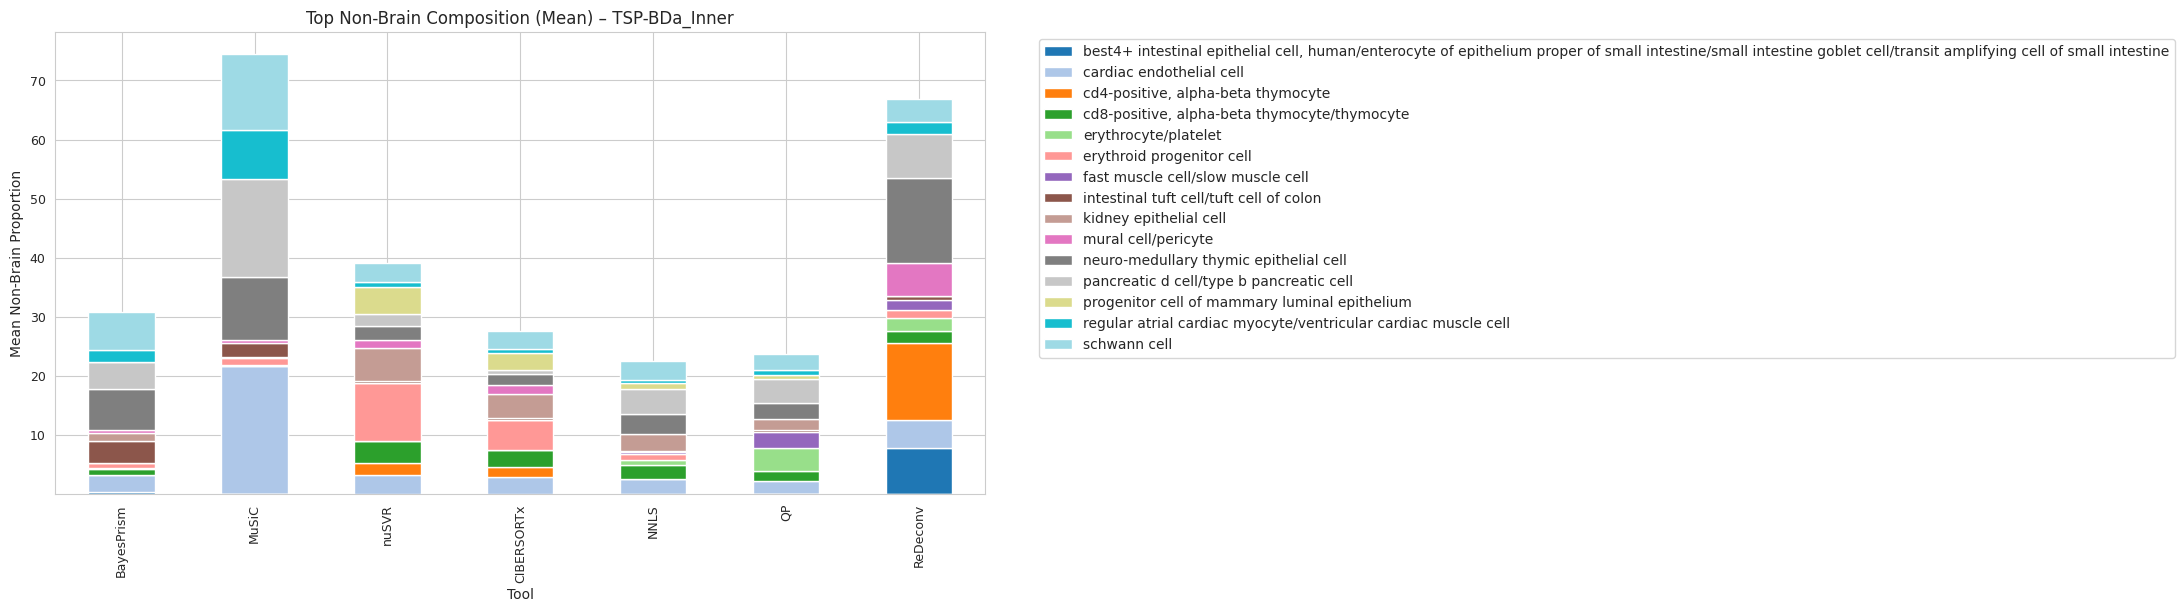

/tmp/ipykernel_2444245/1003928264.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2444245/1003928264.py:127: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


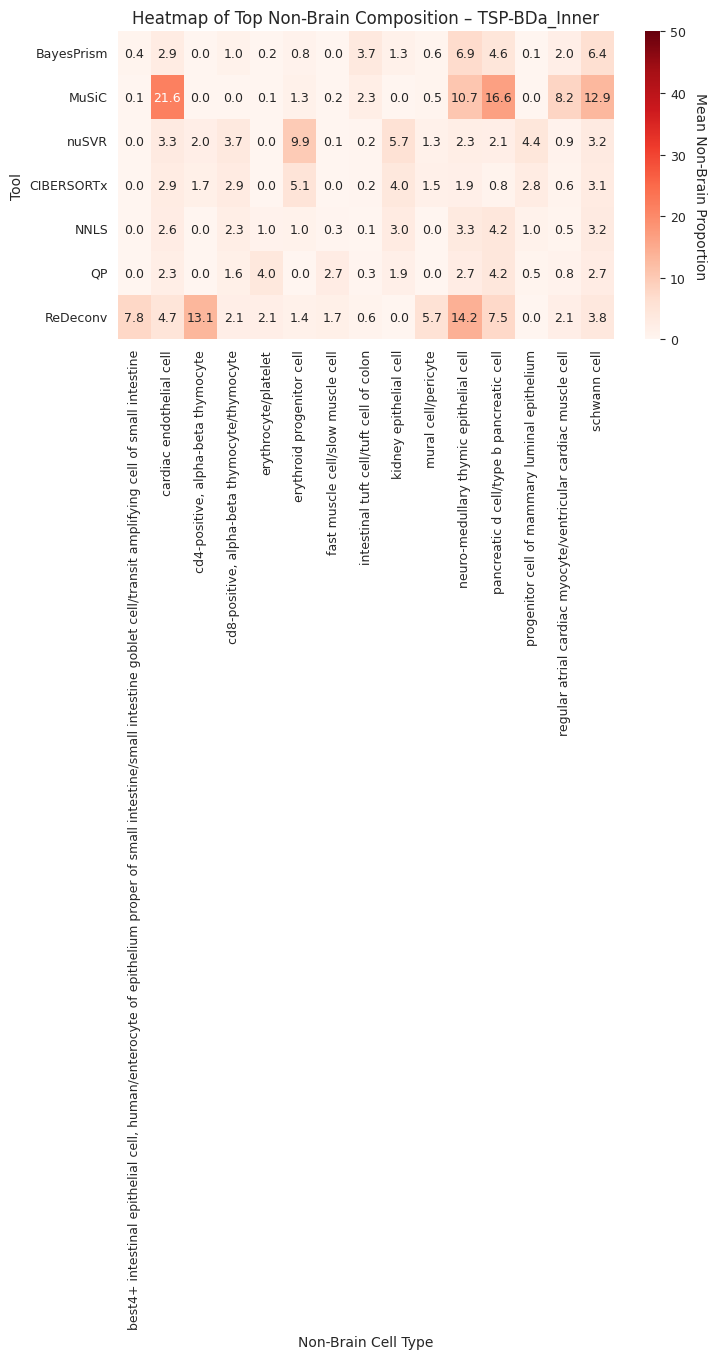

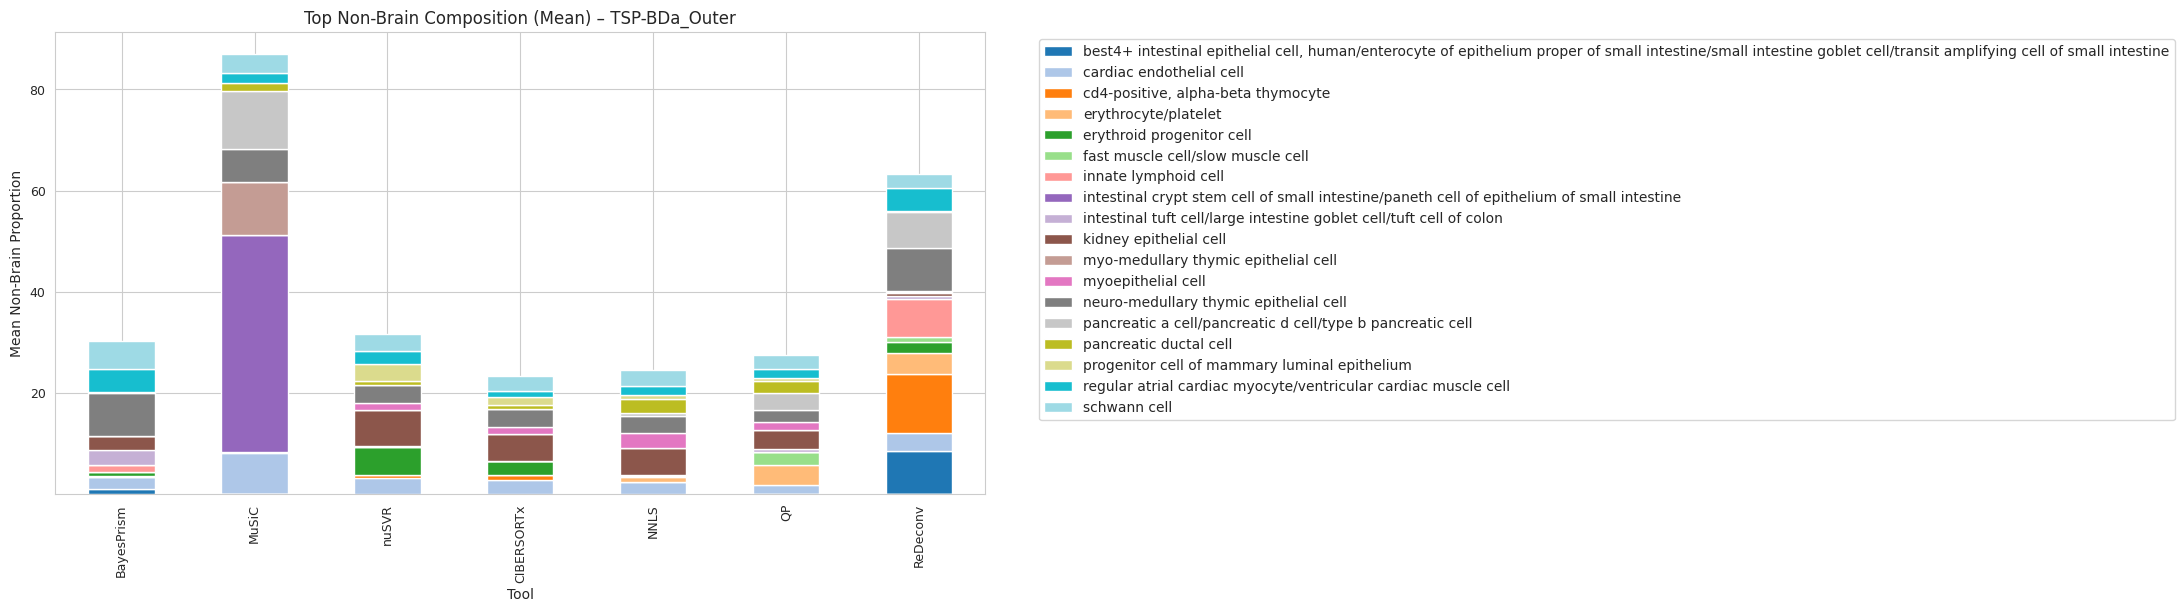

/tmp/ipykernel_2444245/1003928264.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_2444245/1003928264.py:127: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


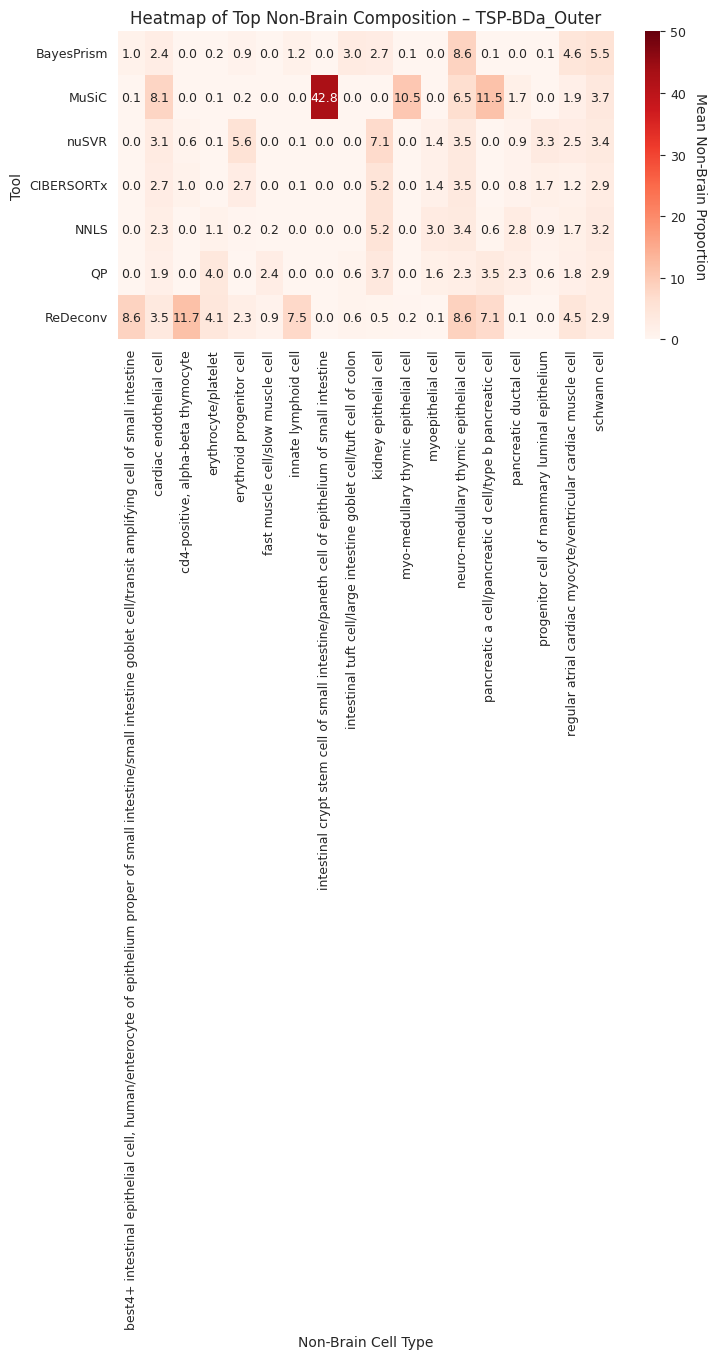

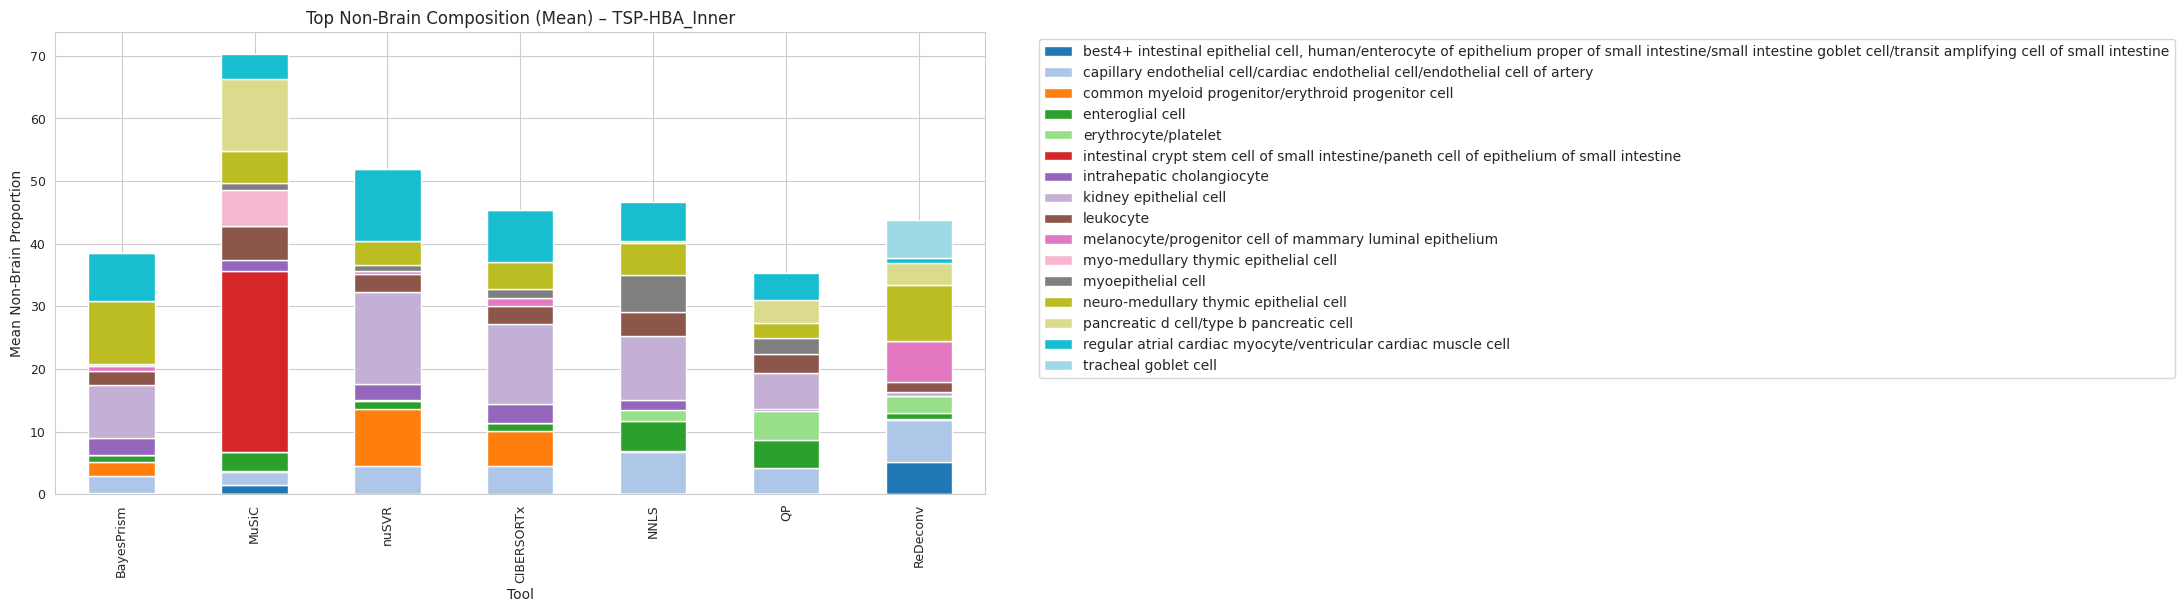

/tmp/ipykernel_2444245/1003928264.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


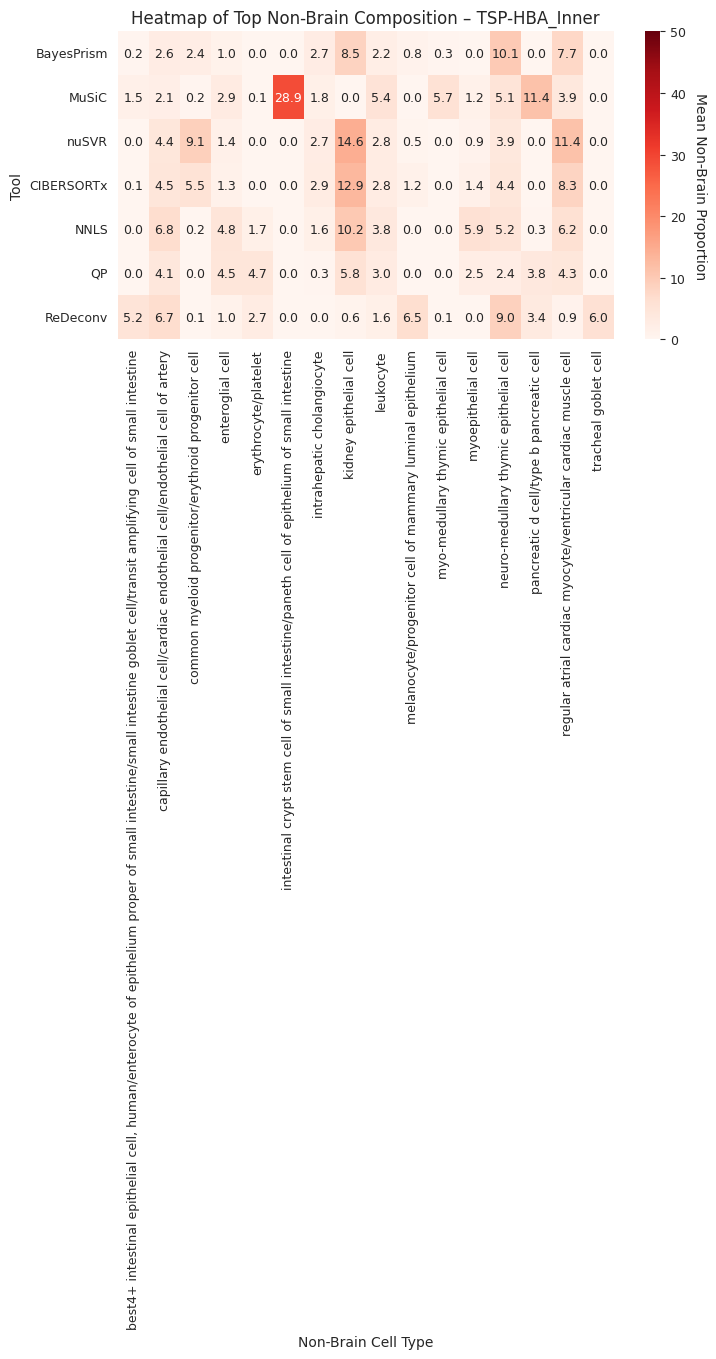

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# -----------------------------
# Publication-friendly styling
# -----------------------------
rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})
sns.set_style("whitegrid")

# Directories
dirs = [
    "TSP-BDa_Inner_300_1500_10-GTEx-Brain",
    "TSP-BDa_Outer_300_1500_10-GTEx-Brain",
    "TSP-HBA_Inner_300_1500_10-GTEx-Brain"
]

# Cell types of interest (already unified across tools)
cell_types_of_interest_HBA = [
    "Bergmann glial cell/astrocyte/ependymal cell", "neuron",
    "endothelial cell/endothelial cell of arteriole/endothelial cell of lymphatic vessel/endothelial cell of venule/vein endothelial cell",
    "mural cell/pericyte", "oligodendrocyte", "oligodendrocyte precursor cell",
    "central nervous system macrophage", "choroid plexus epithelial cell",
    "adventitial cell/fibroblast/mesenchymal stem cell of adipose tissue/stromal cell"
]

cell_types_of_interest_BDa = [
    "neurons", "microglia", "OPC/astrocytes/oligodendrocytes",
    "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell"
]

# Map keywords to tools
tool_map = {
    'BayesPrism': 'BayesPrism',
    'MuSiC': 'MuSiC',
    'CIBERSORTx': 'CIBERSORTx',
    'NNLS': 'NNLS',
    'nuSVR': 'nuSVR',
    'QP': 'QP',
    'ReDeconv': 'ReDeconv'
}
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]

# Collect results
all_data = []

for d in dirs:
    for fname in os.listdir(d):
        if not (fname.endswith("_normalized.txt") or fname.endswith("_normalized.tsv")):
            continue

        fpath = os.path.join(d, fname)
        try:
            df = pd.read_csv(fpath, sep="\t")

            # Decide which set of brain cell types to use
            if "HBA" in d:
                cell_types = cell_types_of_interest_HBA
            else:  # BDa
                cell_types = cell_types_of_interest_BDa

            available_types = [c for c in df.columns if c in cell_types]
            if not available_types:
                continue

            sample_col = df.columns[0]
            non_brain_cols = [c for c in df.columns if c not in available_types + [sample_col]]

            # Determine tool
            tool = next((v for k, v in tool_map.items() if k in fname), "Unknown")

            # Store non-brain details
            if non_brain_cols:
                nb = df[[sample_col] + non_brain_cols].copy()
                nb = nb.melt(id_vars=sample_col, var_name="CellType", value_name="Proportion")
                nb["Tool"] = tool
                nb["Dataset"] = d
                all_data.append(nb)

        except Exception as e:
            print(f"Skipped {fname} (error: {e})")

# Combine everything
if all_data:
    combined = pd.concat(all_data, ignore_index=True)

    for dataset, subdf in combined.groupby("Dataset"):

        # Mean per tool × cell type
        mean_nb = subdf.groupby(["Tool", "CellType"])["Proportion"].mean().reset_index()

        # --- Find top 5 per tool ---
        top_sets = []
        for tool in mean_nb["Tool"].unique():
            tool_df = mean_nb[mean_nb["Tool"] == tool]
            top5 = tool_df.nlargest(5, "Proportion")["CellType"].tolist()
            top_sets.extend(top5)
        top_celltypes = sorted(set(top_sets))  # union of all top 5s

        # Filter to those top cell types
        mean_nb_top = mean_nb[mean_nb["CellType"].isin(top_celltypes)]

        # Pivot for plotting
        pivot_nb = mean_nb_top.pivot(index="Tool", columns="CellType", values="Proportion").fillna(0)
        pivot_nb = pivot_nb.loc[[t for t in tool_order if t in pivot_nb.index]]

        # Clean dataset name for titles
        clean_dataset = dataset.replace("_300_1500_10-GTEx-Brain", "")

        # === Stacked barplot ===
        pivot_nb.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")
        plt.ylabel("Mean Non-Brain Proportion")
        plt.title(f"Top Non-Brain Composition (Mean) – {clean_dataset}")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

        # === Heatmap ===
        plt.figure(figsize=(8, 4))
        ax = sns.heatmap(
            pivot_nb,
            cmap="Reds",
            vmin=0, vmax=50,  
            cbar_kws={'label': 'Mean Non-Brain Proportion'},
            annot=True,
            fmt=".1f",  
            annot_kws={"size": 9}
        )

        # Rotate colorbar label to 270 degrees
        cbar = ax.collections[0].colorbar
        cbar.set_label("Mean Non-Brain Proportion", rotation=270, labelpad=15)

        # Rotate tool labels (y-axis) to vertical
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        plt.title(f"Heatmap of Top Non-Brain Composition – {clean_dataset}")
        plt.ylabel("Tool")
        plt.xlabel("Non-Brain Cell Type")
        plt.tight_layout()
        plt.savefig(f"{clean_dataset}_heatmap.svg", format="svg", bbox_inches="tight")

else:
    print("No non-brain data collected for plotting.")
